<a href="https://colab.research.google.com/github/Eddydev-ALU/Malaria_Diagnosis_Models/blob/main/vestineUmukundwa-Malaria_Diagnosis_CNN_Group6_EvenNumber_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [ ]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [ ]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [ ]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-07 15:10:58--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 108.138.246.46, 108.138.246.9, 108.138.246.89, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|108.138.246.46|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   233MB/s    in 1.4s    

2026-06-07 15:11:00 (233 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


# Transfer Learning with VGG16 for malaria diagnosis

In [ ]:
#finding number if layer vgg16 has
from tensorflow.keras.applications import VGG16

model = VGG16(weights='imagenet')

print(len(model.layers))

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
23


#generating the data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Redefine paths to point to the existing 'cell_images' directory.
training_path = './cell_images'
testing_path = './cell_images'
#data augmentation for making the model robust and for preventing overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
#rescale images from 0–255 to 0–1
test_datagen = ImageDataGenerator(rescale=1./255)


#loading data from folders
def load_data(training_path, testing_path, batch_size=32, img_size=(64,64)):

    # Train data
    train_data = train_datagen.flow_from_directory(
        training_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='training'
    )

    # Validation data
    val_data = train_datagen.flow_from_directory(
        training_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='validation'
    )

    # Test data
    test_data = test_datagen.flow_from_directory(
        testing_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False
    )

    return train_data, val_data, test_data

# Calling load_data to define train_data, val_data, and test_data
train_data, val_data, test_data = load_data(training_path, testing_path, batch_size=32)

print("Class indices:", train_data.class_indices)
print(f"Training batches  : {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Test batches      : {len(test_data)}")

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Found 27558 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Training batches  : 689
Validation batches: 173
Test batches      : 862


#VGG16 Transfer Learning Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

#created build_vgg16_model function
def build_vgg16_model(lr=1e-3, dropout=0.3):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))
    #Freezing VGG16 layers so we only train new layers
    for layer in base_model.layers:
        layer.trainable = False
    #Build new model (classifier)
    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# model summary
build_vgg16_model().summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,239,489 (58.13 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

# craeted Callbacks function
this function will stop training when the model improves ,reduce learning rate when stuck and also save the best model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks = [
    #stop training when model stops improving
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    #for reducing  learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3
    ),
    #save best model
    ModelCheckpoint(
        'best_vgg16_model.keras',
        save_best_only=True
    )
]


#Initial Training

In [ ]:
model = build_vgg16_model(lr=1e-3, dropout=0.3)

#first initialzing training experiment
exp1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.8700 - loss: 0.3098 - val_accuracy: 0.8788 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 103ms/step - accuracy: 0.8951 - loss: 0.2629 - val_accuracy: 0.8877 - val_loss: 0.2700 - learning_rate: 0.0010
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 102ms/step - accuracy: 0.8999 - loss: 0.2577 - val_accuracy: 0.8909 - val_loss: 0.2568 - learning_rate: 0.0010
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 77s 112ms/step - accuracy: 0.9042 - loss: 0.2448 - val_accuracy: 0.8851 - val_loss: 0.2851 - learning_rate: 0.0010
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 76s 104ms/step - accuracy: 0.9102 - loss: 0.2348 - val_accuracy: 0.9024 - val_loss: 0.2400 - learning_rate: 0.0010
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 104ms/step - accuracy: 0.9092 - loss: 0.2363 - val_accuracy: 0.9058 - val_loss: 0.2405 - learning_rate: 0.0010
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 102ms/step - accuracy: 0.9

These functions are used for evaluation across all seven experiments, ensuring metric differences reflect model performance rather than evaluation inconsistencies. We report accuracy, precision, recall, F1-score, confusion matrices, and ROC/AUC curves. Learning curves diagnose overfitting or underfitting, while confusion matrices show prediction errors. ROC/AUC evaluates threshold-independent discriminative ability (Fawcett, 2006).

In [ ]:
#funtctions created for all experiments to generate plots

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns # Assuming seaborn is needed

def plot_learning_curves(experiments, title='Learning Curves'):
    """Reusable training/validation curves for all experiments (exp1–exp7)."""

    fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Accuracy
    ax1.plot(experiments.history['accuracy'], label='Train Accuracy')
    ax1.plot(experiments.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(experiments.history['loss'], label='Train Loss')
    ax2.plot(experiments.history['val_loss'], label='Val Loss')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    pyplot.tight_layout()
    pyplot.savefig(f"{title.replace(' ', '_')}_learning.png", dpi=150)
    pyplot.show()

def evaluate_model(model, generator, title='Evaluation'):
    generator.reset()

    # Predictions
    y_prob = model.predict(generator, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    y_true = generator.classes

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=['Uninfected', 'Parasitized'],
        output_dict=True
    )

    acc  = report['accuracy']
    prec = report['Parasitized']['precision']
    rec  = report['Parasitized']['recall']
    f1   = report['Parasitized']['f1-score']

    # ROC (FIXED SAFE VERSION)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plots
    fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Uninfected', 'Parasitized'],
        yticklabels=['Uninfected', 'Parasitized'],
        ax=ax1
    )

    ax1.set_title('Confusion Matrix')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')

    ax2.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    ax2.plot([0, 1], [0, 1], 'k--')
    ax2.set_title('ROC Curve')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    pyplot.tight_layout()
    pyplot.savefig(f"{title.replace(' ', '_')}_eval.png", dpi=150)
    pyplot.show()

    print(f"\n{'─'*50}")
    print(f"{title}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC      : {roc_auc:.4f}")
    print(f"{'─'*50}\n")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": roc_auc
    }

def run_experiment(model, experiments, test_data, exp_name):
    """
    Full pipeline for exp1–exp7:
    - learning curves
    - evaluation
    - returns metrics for table
    """

    print(f"\n================ {exp_name} ================\n")

    # Learning curves
    plot_learning_curves(experiments, title=f"{exp_name}")

    # Evaluation
    metrics = evaluate_model(model, test_data, title=f"{exp_name}")

    return metrics

#plots for experiment 1


================ Experiment 1 initial training plots ================



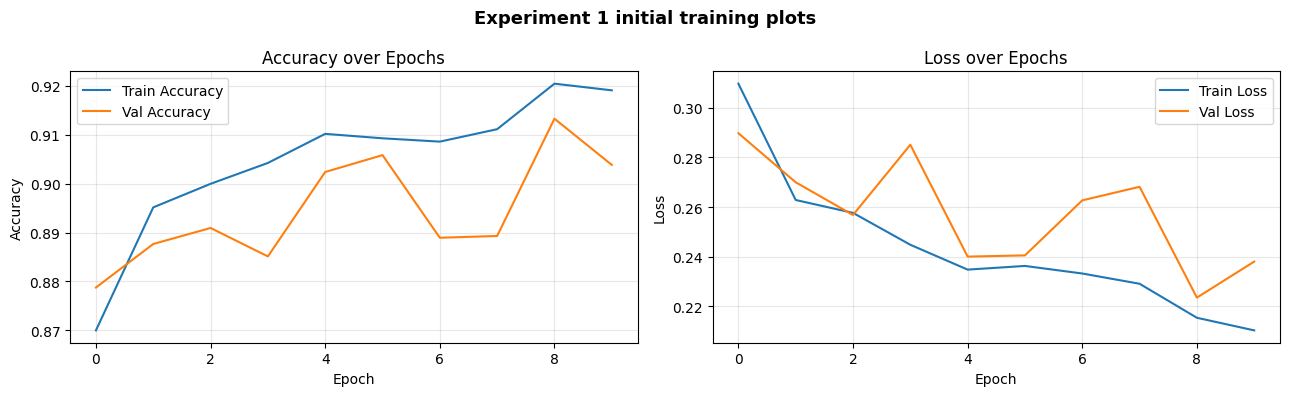

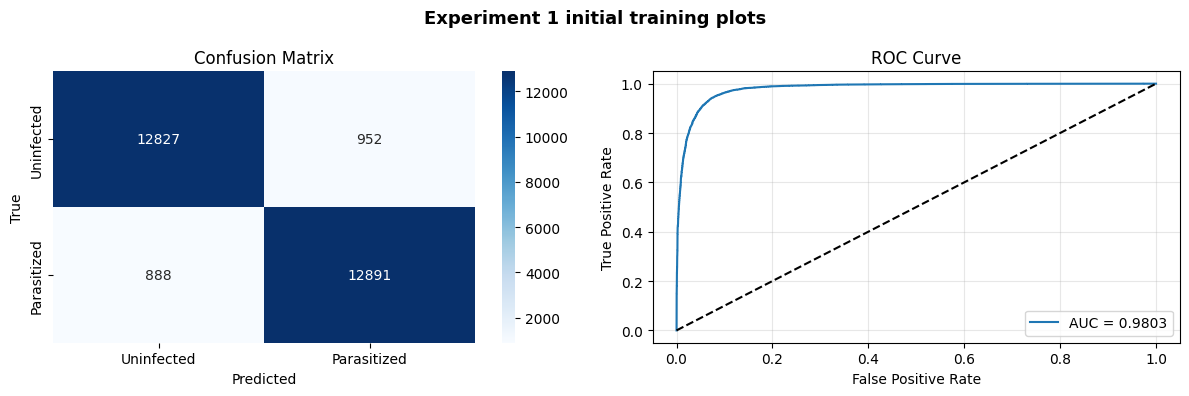


──────────────────────────────────────────────────
Experiment 1 initial training plots
Accuracy : 0.9332
Precision: 0.9312
Recall   : 0.9356
F1-Score : 0.9334
AUC      : 0.9803
──────────────────────────────────────────────────



In [ ]:
metrics_exp1 = run_experiment(
    model=model, # Changed from exp1 to model
    experiments=exp1,
    test_data=test_data,
    exp_name="Experiment 1 initial training plots"
)

#experiment 2
changed learning rate(learning_rate=0.0001)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Found 27558 images belonging to 2 classes.
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 77s 108ms/step - accuracy: 0.8398 - loss: 0.3624 - val_accuracy: 0.8635 - val_loss: 0.3121 - learning_rate: 1.0000e-04
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 108ms/step - accuracy: 0.8899 - loss: 0.2751 - val_accuracy: 0.8835 - val_loss: 0.2731 - learning_rate: 1.0000e-04
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 106ms/step - accuracy: 0.8971 - loss: 0.2574 - val_accuracy: 0.8969 - val_loss: 0.2603 - learning_rate: 1.0000e-04
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 108ms/step - accuracy: 0.9048 - loss: 0.2451 - val_accuracy: 0.8935 - val_loss: 0.2605 - learning_rate: 2.0000e-05
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 107ms/step - accuracy: 0.9065 - loss: 0.2386 - val_accuracy: 0.8882 - val_loss: 0.2609 - learning_rate: 2.0000e-05

================ Experiment 2  training plots ================



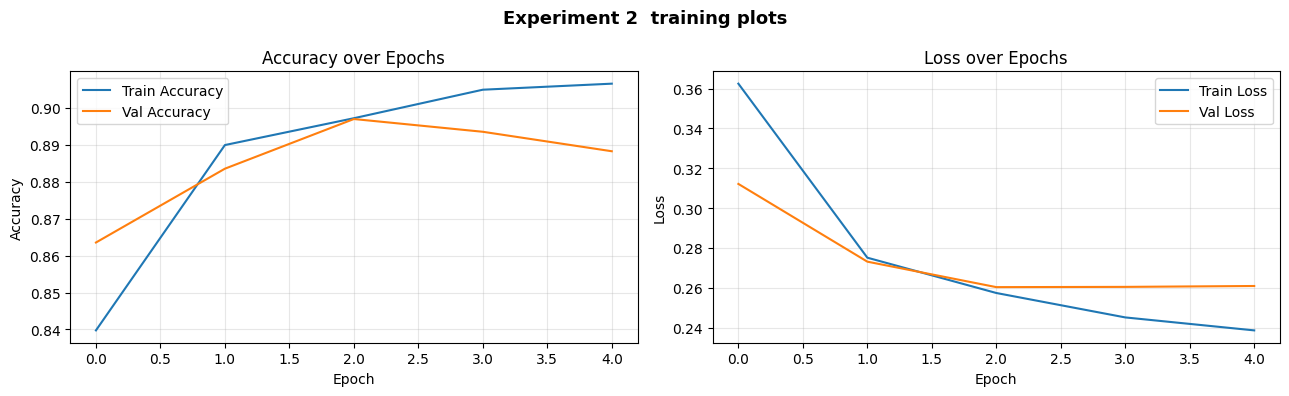

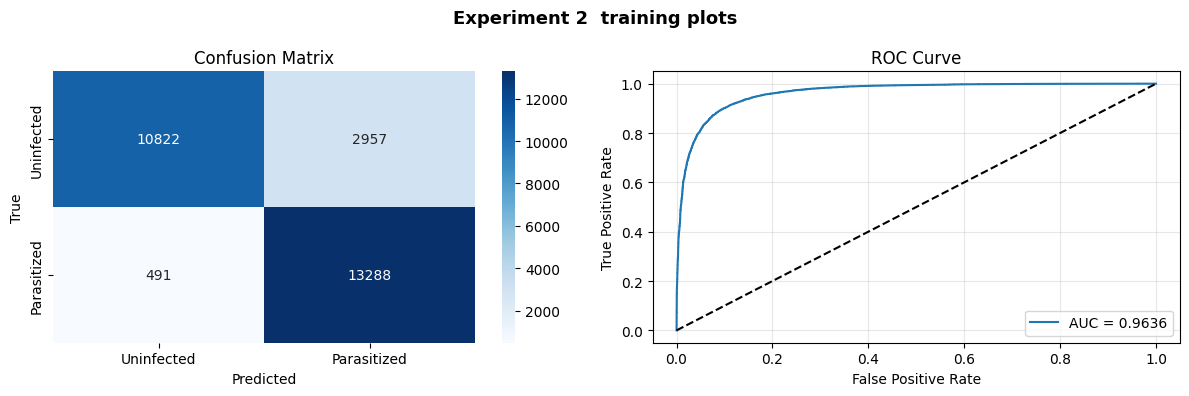


──────────────────────────────────────────────────
Experiment 2  training plots
Accuracy : 0.8749
Precision: 0.8180
Recall   : 0.9644
F1-Score : 0.8852
AUC      : 0.9636
──────────────────────────────────────────────────



In [ ]:
#loading data from folders
train_data, val_data, test_data = load_data(
    training_path,
    testing_path,
    batch_size=32
)

#calling created build_vgg16_model with 0.0001 learning rate
model = build_vgg16_model(lr=1e-4)
exp2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)
#calling funtion for plots
metrics_exp2 = run_experiment(
    model=model, # Changed from exp2 to model
    experiments=exp2,
    test_data=test_data,
    exp_name="Experiment 2  training plots"
)

#experiment 3
changed learning rate(learning_rate=0.0001) ,batch size=64,epochs=5

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Found 27558 images belonging to 2 classes.
Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 74s 205ms/step - accuracy: 0.8287 - loss: 0.3824 - val_accuracy: 0.8731 - val_loss: 0.3042 - learning_rate: 1.0000e-04
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 68s 196ms/step - accuracy: 0.8852 - loss: 0.2850 - val_accuracy: 0.8824 - val_loss: 0.2809 - learning_rate: 1.0000e-04
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 67s 194ms/step - accuracy: 0.8959 - loss: 0.2661 - val_accuracy: 0.8933 - val_loss: 0.2690 - learning_rate: 1.0000e-04
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 67s 195ms/step - accuracy: 0.8992 - loss: 0.2552 - val_accuracy: 0.8868 - val_loss: 0.2745 - learning_rate: 2.0000e-05
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 67s 195ms/step - accuracy: 0.9004 - loss: 0.2543 - val_accuracy: 0.8835 - val_loss: 0.2725 - learning_rate: 2.0000e-05

================ Experiment 3  training plots ================



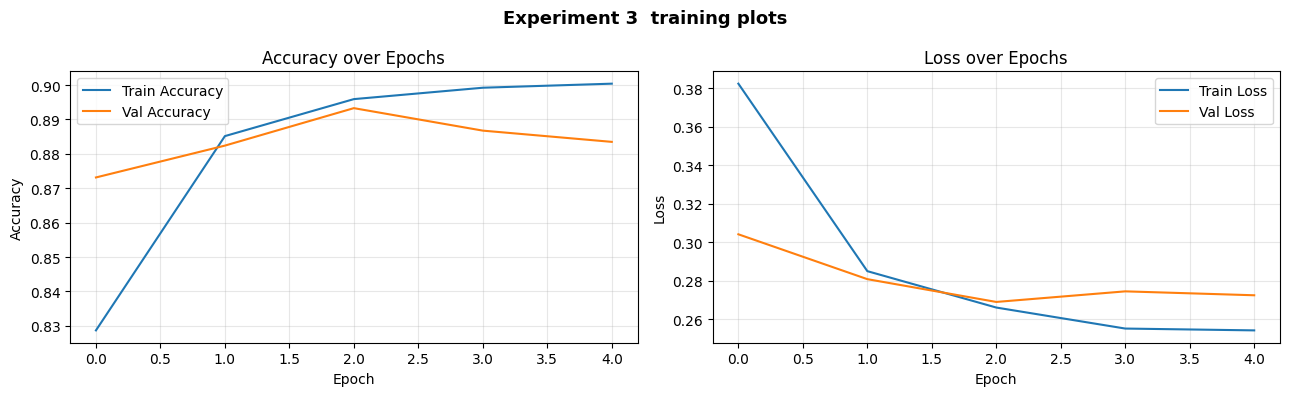

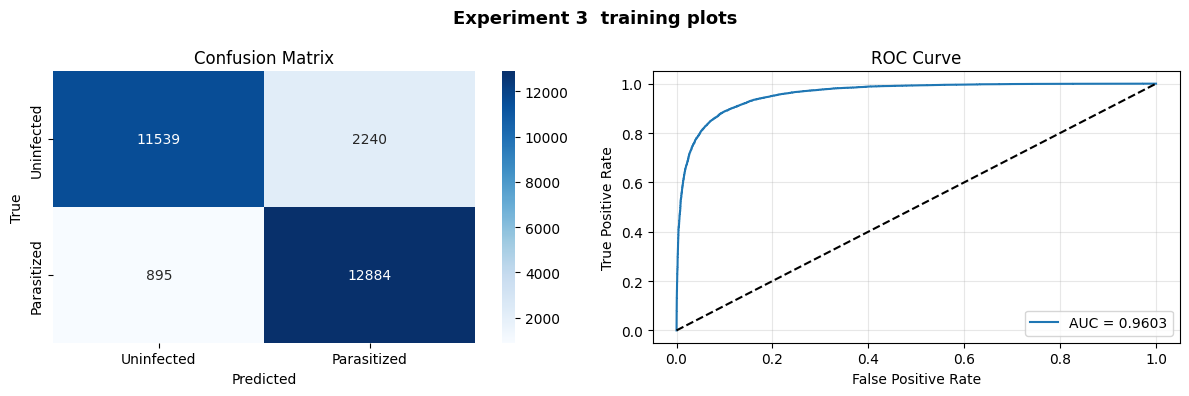


──────────────────────────────────────────────────
Experiment 3  training plots
Accuracy : 0.8862
Precision: 0.8519
Recall   : 0.9350
F1-Score : 0.8915
AUC      : 0.9603
──────────────────────────────────────────────────



In [ ]:

#loading data from folders with 64 batch size
train_data, val_data, test_data = load_data(
    training_path,
    testing_path,
    batch_size=64
)
#calling created build_vgg16_model with 0.0001 learning rate
model = build_vgg16_model(lr=1e-4)
exp3 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)
#calling funtion for plots
metrics_exp3 = run_experiment(
    model=model, # Changed from exp3 to model
    experiments=exp3,
    test_data=test_data,
    exp_name="Experiment 3  training plots"
)

#experiment 4
changed dropouts to 0.5 and batch size=32 ,epoches=5

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Found 27558 images belonging to 2 classes.
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 76s 105ms/step - accuracy: 0.8587 - loss: 0.3287 - val_accuracy: 0.8877 - val_loss: 0.2771 - learning_rate: 0.0010
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 77s 112ms/step - accuracy: 0.8900 - loss: 0.2772 - val_accuracy: 0.8849 - val_loss: 0.2717 - learning_rate: 0.0010
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 104ms/step - accuracy: 0.8945 - loss: 0.2659 - val_accuracy: 0.9025 - val_loss: 0.2471 - learning_rate: 0.0010
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 104ms/step - accuracy: 0.9083 - loss: 0.2426 - val_accuracy: 0.8940 - val_loss: 0.2517 - learning_rate: 2.0000e-04
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 103ms/step - accuracy: 0.9076 - loss: 0.2332 - val_accuracy: 0.8926 - val_loss: 0.2566 - learning_rate: 2.0000e-04

================ Experiment 4 training plots ================



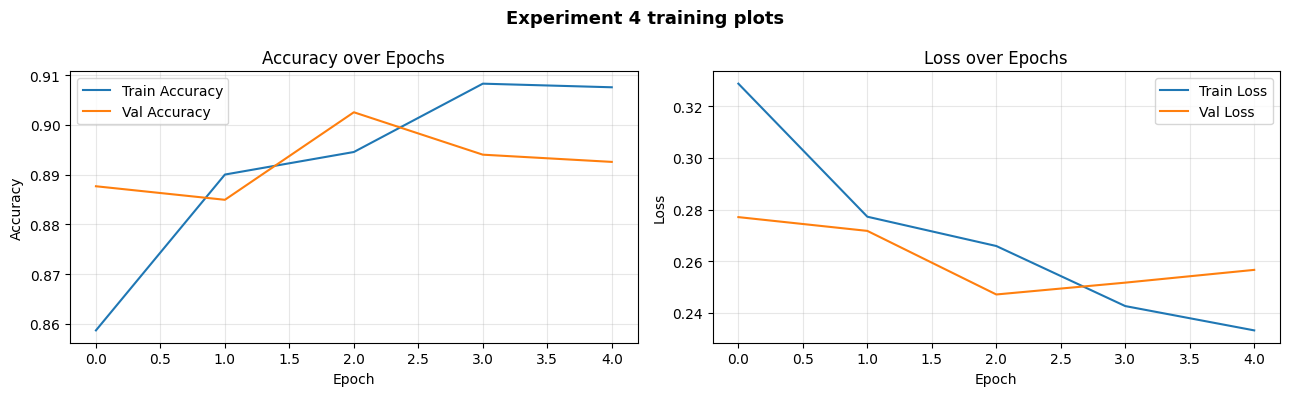

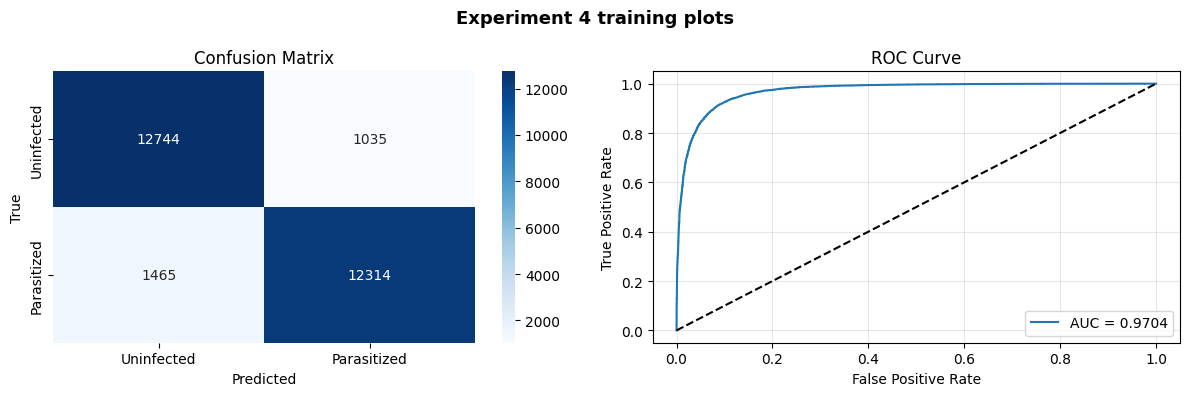


──────────────────────────────────────────────────
Experiment 4 training plots
Accuracy : 0.9093
Precision: 0.9225
Recall   : 0.8937
F1-Score : 0.9078
AUC      : 0.9704
──────────────────────────────────────────────────



In [ ]:
#loading data from folders
train_data, val_data, test_data = load_data(
    training_path,
    testing_path,
    batch_size=32
)
#changing dropout to 0.5
model = build_vgg16_model(dropout=0.5)
exp4 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)
#calling funtion for plots
metrics_exp4 = run_experiment(
    model=model, # Changed from exp4 to model
    experiments=exp4,
    test_data=test_data,
    exp_name="Experiment 4 training plots"
)

#experinent 5-7 using fine tuning


## Fine-Tuning VGG16

After training the custom classification , the last convolutional layers of VGG16 were unfrozen. This allows the model to adapt ImageNet features specifically to malaria cell images.

A very small learning rate was used to prevent destroying previously learned weights.

#experiment 5


#unfreezing last 2 layers

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 77s 106ms/step - accuracy: 0.8867 - loss: 0.2722 - val_accuracy: 0.9062 - val_loss: 0.2293 - learning_rate: 1.0000e-04
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 105ms/step - accuracy: 0.9170 - loss: 0.2193 - val_accuracy: 0.9094 - val_loss: 0.2310 - learning_rate: 1.0000e-04
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 103ms/step - accuracy: 0.9205 - loss: 0.2128 - val_accuracy: 0.9118 - val_loss: 0.2286 - learning_rate: 1.0000e-04
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 104ms/step - accuracy: 0.9300 - loss: 0.1901 - val_accuracy: 0.9129 - val_loss: 0.2195 - learning_rate: 2.0000e-05
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 104ms/step - accuracy: 0.9319 - loss: 0.1880 - val_accuracy: 0.9176 - val_loss: 0.2065 - learning_rate: 2.0000e-05

================ Experiment 5 training plots ================



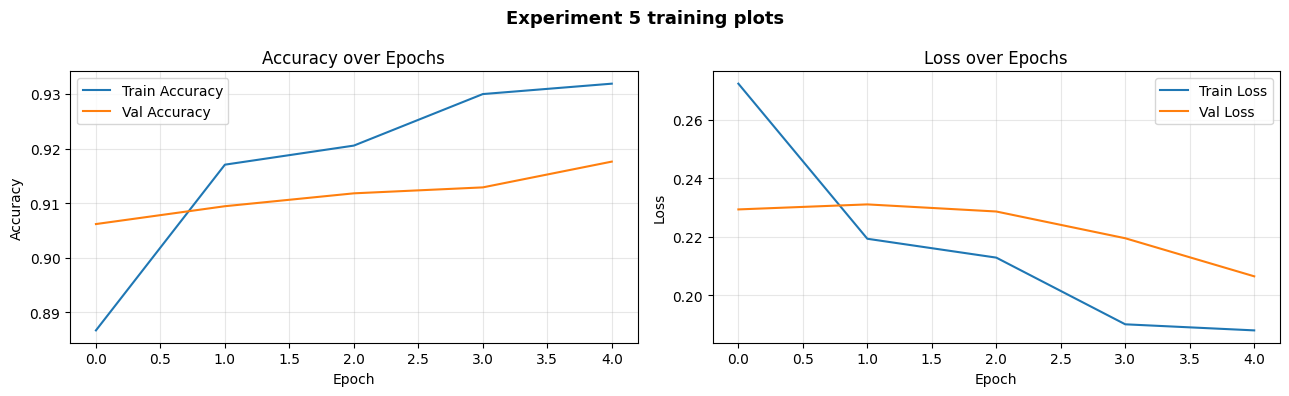

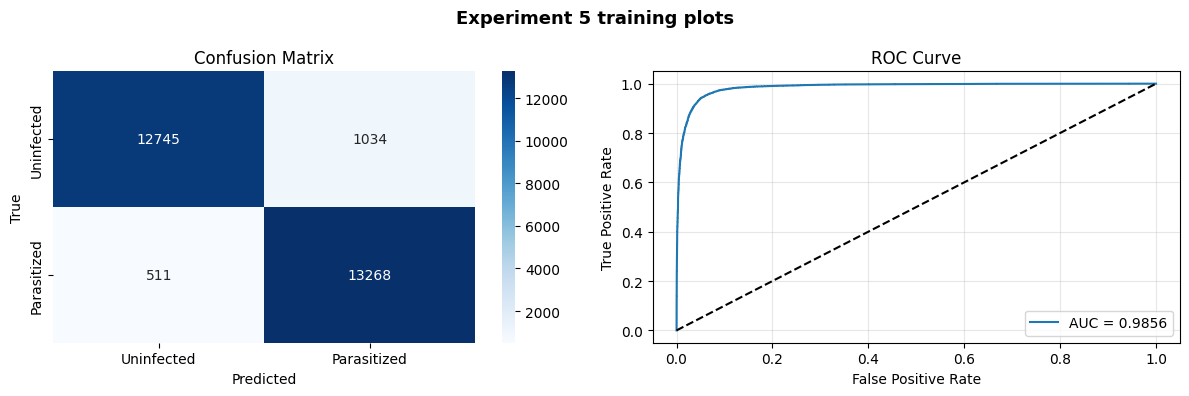


──────────────────────────────────────────────────
Experiment 5 training plots
Accuracy : 0.9439
Precision: 0.9277
Recall   : 0.9629
F1-Score : 0.9450
AUC      : 0.9856
──────────────────────────────────────────────────



In [ ]:
#unfreezing the last 2 layers
model = build_vgg16_model(lr=1e-4)

# Get a reference to the VGG16 base model (which is the first layer of our Sequential model)
vgg_base_model = model.layers[0]

# Unfreeze the last 2 layers of the VGG16 base model
for layer in vgg_base_model.layers[-2:]:
    layer.trainable = True

# Recompile the model after unfreezing layers for the changes to take effect
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-4), # Use the fine-tuning learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

exp5 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)
#calling funtion for plots
metrics_exp5 = run_experiment(
    model=model,
    experiments=exp5,
    test_data=test_data,
    exp_name="Experiment 5 training plots"
)

#experiment 6
unfreezing last 4 layers and changing learning late to 0.00001


Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 85s 115ms/step - accuracy: 0.8854 - loss: 0.2700 - val_accuracy: 0.9018 - val_loss: 0.2354 - learning_rate: 1.0000e-05
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 105ms/step - accuracy: 0.9282 - loss: 0.1944 - val_accuracy: 0.9156 - val_loss: 0.2194 - learning_rate: 1.0000e-05
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 105ms/step - accuracy: 0.9341 - loss: 0.1804 - val_accuracy: 0.9260 - val_loss: 0.1960 - learning_rate: 1.0000e-05
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 108ms/step - accuracy: 0.9385 - loss: 0.1702 - val_accuracy: 0.9093 - val_loss: 0.2379 - learning_rate: 1.0000e-05
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 104ms/step - accuracy: 0.9406 - loss: 0.1671 - val_accuracy: 0.9187 - val_loss: 0.2057 - learning_rate: 1.0000e-05
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 105ms/step - accuracy: 0.9411 - loss: 0.1643 - val_accuracy: 0.9229 - val_loss: 0.1945 - learning_rate: 1.0000e-05
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 10

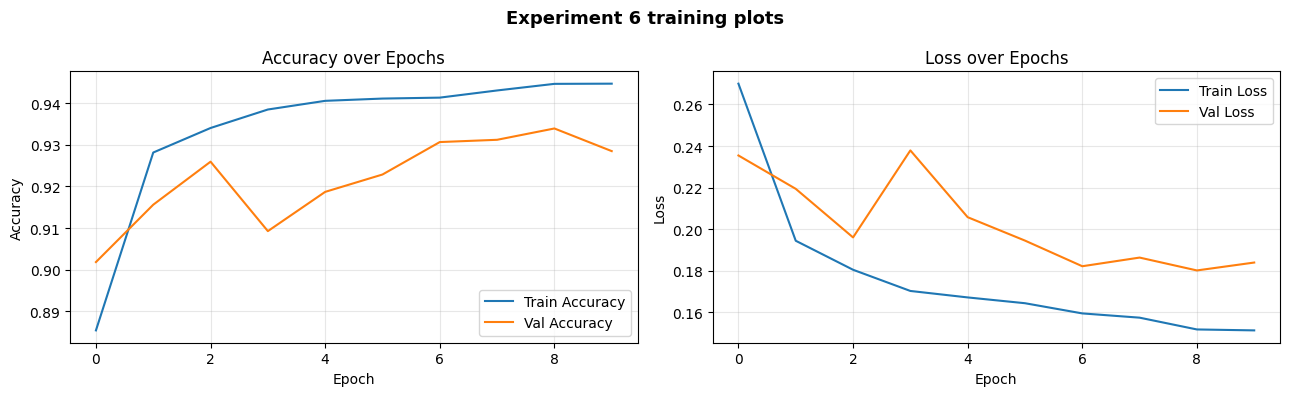

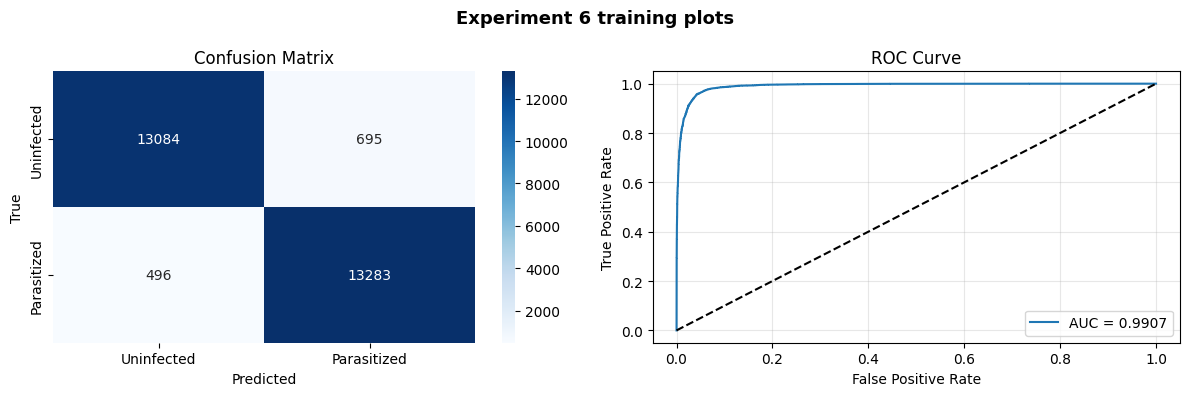


──────────────────────────────────────────────────
Experiment 6 training plots
Accuracy : 0.9568
Precision: 0.9503
Recall   : 0.9640
F1-Score : 0.9571
AUC      : 0.9907
──────────────────────────────────────────────────



In [ ]:
# Initialize the model before attempting to access its base_model for unfreezing
model = build_vgg16_model(lr=1e-5)

# Get a reference to the VGG16 base model (which is the first layer of our Sequential model)
vgg_base_model = model.layers[0]

#unfreezing the last 4 layers of the VGG16 base model
for layer in vgg_base_model.layers[-4:]:
    layer.trainable = True

# Recompile the model after unfreezing layers for the changes to take effect
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-5), # Use the fine-tuning learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

exp6 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)
#calling funtion for plots
metrics_exp6 = run_experiment(
    model=model, # Changed from exp6 to model
    experiments=exp6,
    test_data=test_data,
    exp_name="Experiment 6 training plots"
)

#experiment 7
unfreezing last 6 layers and using learning rate =0.00001

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 86s 118ms/step - accuracy: 0.7772 - loss: 0.4611 - val_accuracy: 0.8784 - val_loss: 0.2874 - learning_rate: 1.0000e-06
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 107ms/step - accuracy: 0.8969 - loss: 0.2566 - val_accuracy: 0.9024 - val_loss: 0.2376 - learning_rate: 1.0000e-06
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 107ms/step - accuracy: 0.9146 - loss: 0.2258 - val_accuracy: 0.9136 - val_loss: 0.2209 - learning_rate: 1.0000e-06
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 107ms/step - accuracy: 0.9179 - loss: 0.2159 - val_accuracy: 0.9183 - val_loss: 0.2108 - learning_rate: 2.0000e-07
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 108ms/step - accuracy: 0.9236 - loss: 0.2079 - val_accuracy: 0.9162 - val_loss: 0.2138 - learning_rate: 2.0000e-07

================ Experiment 7 training plots ================



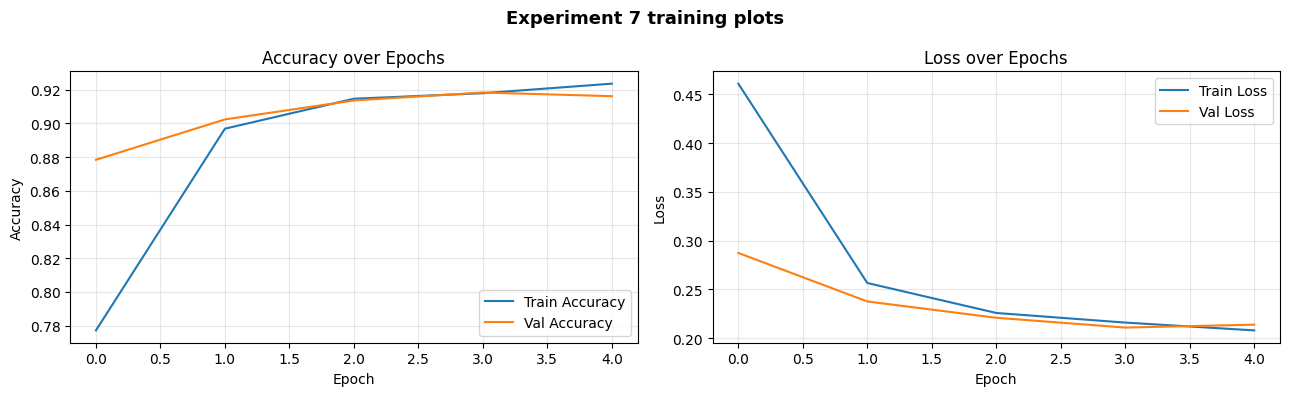

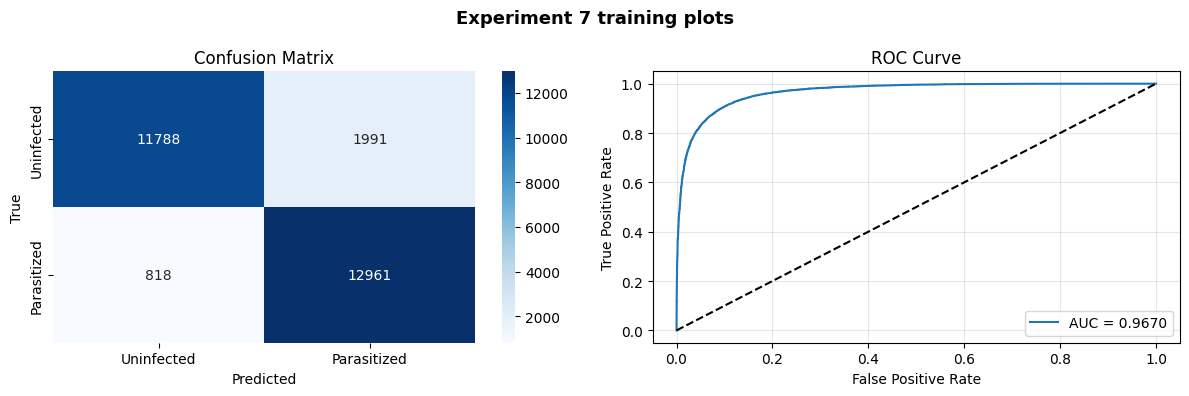


──────────────────────────────────────────────────
Experiment 7 training plots
Accuracy : 0.8981
Precision: 0.8668
Recall   : 0.9406
F1-Score : 0.9022
AUC      : 0.9670
──────────────────────────────────────────────────



In [ ]:
# Initialize the model before attempting to access its base_model for unfreezing
model = build_vgg16_model(lr=1e-6)

# Get a reference to the VGG16 base model (which is the first layer of our Sequential model)
vgg_base_model = model.layers[0]

#unfreezing the last 6 layers of the VGG16 base model
for layer in vgg_base_model.layers[-6:]:
    layer.trainable = True

# Recompile the model after unfreezing layers for the changes to take effect
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-6), # Use the fine-tuning learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

exp7 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)
#calling the plot function
metrics_exp7 = run_experiment(
    model=model, # Changed from exp7 to model
    experiments=exp7,
    test_data=test_data,
    exp_name="Experiment 7 training plots"
)

In [ ]:
import pandas as pd

# Consolidated results table across all 7 experiments
results_baseline = [
    {"experiment": "Experiment 1", **metrics_exp1},
    {"experiment": "Experiment 2", **metrics_exp2},
    {"experiment": "Experiment 3", **metrics_exp3},
    {"experiment": "Experiment 4", **metrics_exp4},
    {"experiment": "Experiment 5", **metrics_exp5},
    {"experiment": "Experiment 6", **metrics_exp6},
    {"experiment": "Experiment 7", **metrics_exp7}
]
df = pd.DataFrame(results_baseline).set_index('experiment')
df = df[['accuracy', 'precision', 'recall', 'f1', 'auc']].round(4)

print("\n=== Baseline CNN — All 7 Experiments ===")
print(df.to_string())

best = df['f1'].idxmax()
print(f"\n✓ Best F1 Score: {best}  →  {df.loc[best, 'f1']:.4f}")


=== Baseline CNN — All 7 Experiments ===
              accuracy  precision  recall      f1     auc
experiment                                               
Experiment 1    0.9332     0.9312  0.9356  0.9334  0.9803
Experiment 2    0.8749     0.8180  0.9644  0.8852  0.9636
Experiment 3    0.8862     0.8519  0.9350  0.8915  0.9603
Experiment 4    0.9093     0.9225  0.8937  0.9078  0.9704
Experiment 5    0.9439     0.9277  0.9629  0.9450  0.9856
Experiment 6    0.9568     0.9503  0.9640  0.9571  0.9907
Experiment 7    0.8981     0.8668  0.9406  0.9022  0.9670

✓ Best F1 Score: Experiment 6  →  0.9571


#saving the best model

In [ ]:
# Save the best performing model based on F1 score
# From the results, 'Experiment 6' has the best F1 score, and 'model' holds this state.
best_model = model
best_model.save('baseline_cnn_best.keras')
print("Saved → baseline_cnn_best.keras")

Saved → baseline_cnn_best.keras
